# Train Variational Quantum Circuits by using f-evovaq and Qiskit

## 1) Training a Variational Quantum Classifier through a Memetic Algorithm

#### Importing modules

In [3]:
import numpy as np
import cupy as cp
from functools import partial
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from qiskit.circuit.library import TwoLocal
from qiskit_aer.quantum_info import AerStatevector
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from fevovaq.problem import Problem
from fevovaq.GeneticAlgorithm import GA
from fevovaq.HillClimbing import HC
from fevovaq.MemeticAlgorithm import MA
from fevovaq.tools.operators import sel_tournament, cx_uniform, mut_gaussian, sel_best

#### Uploading the classical data

In [4]:
iris = load_iris()

# For the sake of simplicity, we consider all the four features but only two classes
iris_data = iris.data[:100, :4]
iris_target = iris.target[:100]   # 0 or 1

# Split into train and test subsets
train_data, test_data, train_labels, test_labels = train_test_split(iris_data, iris_target, test_size=0.2,
                                                                    random_state=42)

# Pre-processing
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
scaler.fit(train_data)
train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

#### Building the Variational Quantum Classifier

In [5]:
def AngleEncoding(n_qubits, rotation="ry"):
    features = ParameterVector('f', n_qubits)

    qc = QuantumCircuit(n_qubits, 1)

    for i in range(n_qubits):
        if rotation == "rx":
            qc.rx(features[i], i)
        elif rotation == "ry":
            qc.ry(features[i], i)
        elif rotation == "rz":
            qc.rz(features[i], i)
        else:
            raise ValueError("rotation must be 'rx', 'ry', or 'rz'")

    return qc

In [6]:
# Encode classical data in a quantum system through a FeatureMap
reps = 5
n_qubits = train_data.shape[1]  # Number of qubits

feature_map = AngleEncoding(n_qubits)

# Define an Ansatz to be trained
ansatz = TwoLocal(num_qubits=n_qubits, entanglement='reverse_linear', rotation_blocks='u3', reps=reps,
              entanglement_blocks='cx', skip_final_rotation_layer=True)

# Put together our quantum classifier
classifier = feature_map.compose(ansatz)

classifier.decompose().draw()

┌─────────────┐ ┌────────────────────┐                               »
q_0: ┤ R(f[0],π/2) ├─┤ U3(θ[2],θ[1],θ[0]) ├───────────────────────────────»
     ├─────────────┤ ├────────────────────┤                               »
q_1: ┤ R(f[1],π/2) ├─┤ U3(θ[5],θ[4],θ[3]) ├──────────────────■────────────»
     ├─────────────┤ ├────────────────────┤                ┌─┴─┐          »
q_2: ┤ R(f[2],π/2) ├─┤ U3(θ[8],θ[7],θ[6]) ├───■────────────┤ X ├──────────»
     ├─────────────┤┌┴────────────────────┴┐┌─┴─┐┌─────────┴───┴─────────┐»
q_3: ┤ R(f[3],π/2) ├┤ U3(θ[11],θ[10],θ[9]) ├┤ X ├┤ U3(θ[23],θ[22],θ[21]) ├»
     └─────────────┘└──────────────────────┘└───┘└───────────────────────┘»
c: 1/═════════════════════════════════════════════════════════════════════»
                                                                          »
«                              ┌───────────────────────┐»
«q_0: ────────────■────────────┤ U3(θ[14],θ[13],θ[12]) ├»
«               ┌─┴─┐          ├───────────────────────┤»
«q_1: ──────────┤ X ├──────────┤ U3(θ[17],θ[16],θ[15]) ├»
«     ┌─────────┴───┴─────────┐└───────────────────────┘»
«q_2: ┤ U3(θ[20],θ[19],θ[18]) ├────────────■────────────»
«     └───────────────────────┘          ┌─┴─┐          »
«q_3: ───────────────────────────────────┤ X ├──────────»
«                                        └───┘          »
«c: 1/══════════════════════════════════════════════════»
«                                                       »
«                                                       »
«q_0: ─────────────────────────────────────■────────────»
«                                        ┌─┴─┐          »
«q_1: ────────────■──────────────────────┤ X ├──────────»
«               ┌─┴─┐          ┌─────────┴───┴─────────┐»
«q_2: ──────────┤ X ├──────────┤ U3(θ[32],θ[31],θ[30]) ├»
«     ┌─────────┴───┴─────────┐└───────────────────────┘»
«q_3: ┤ U3(θ[35],θ[34],θ[33]) ├─────────────────────────»
«     └───────────────────────┘                         »
«c: 1/══════════════════════════════════════════════════»
«                                                       »
«     ┌───────────────────────┐                         »
«q_0: ┤ U3(θ[26],θ[25],θ[24]) ├─────────────────────────»
«     ├───────────────────────┤                         »
«q_1: ┤ U3(θ[29],θ[28],θ[27]) ├────────────■────────────»
«     └───────────────────────┘          ┌─┴─┐          »
«q_2: ────────────■──────────────────────┤ X ├──────────»
«               ┌─┴─┐          ┌─────────┴───┴─────────┐»
«q_3: ──────────┤ X ├──────────┤ U3(θ[47],θ[46],θ[45]) ├»
«               └───┘          └───────────────────────┘»
«c: 1/══════════════════════════════════════════════════»
«                                                       »
«                              ┌───────────────────────┐»
«q_0: ────────────■────────────┤ U3(θ[38],θ[37],θ[36]) ├»
«               ┌─┴─┐          ├───────────────────────┤»
«q_1: ──────────┤ X ├──────────┤ U3(θ[41],θ[40],θ[39]) ├»
«     ┌─────────┴───┴─────────┐└───────────────────────┘»
«q_2: ┤ U3(θ[44],θ[43],θ[42]) ├────────────■────────────»
«     └───────────────────────┘          ┌─┴─┐          »
«q_3: ───────────────────────────────────┤ X ├──────────»
«                                        └───┘          »
«c: 1/══════════════════════════════════════════════════»
«                                                       »
«                                                       »
«q_0: ─────────────────────────────────────■────────────»
«                                        ┌─┴─┐          »
«q_1: ────────────■──────────────────────┤ X ├──────────»
«               ┌─┴─┐          ┌─────────┴───┴─────────┐»
«q_2: ──────────┤ X ├──────────┤ U3(θ[56],θ[55],θ[54]) ├»
«     ┌─────────┴───┴─────────┐└───────────────────────┘»
«q_3: ┤ U3(θ[59],θ[58],θ[57]) ├─────────────────────────»
«     └───────────────────────┘                         »
«c: 1/══════════════════════════════════════════════════»
«                                    

In [7]:
def get_label(params, classifier, test_data, problem):
    xp = problem.xp
    if xp.__name__ == 'cupy':
        params = xp.asnumpy(params)

    bound_circuit = classifier.assign_parameters(np.concatenate((test_data, params)))
    sv = AerStatevector(bound_circuit , device='GPU')

    probs = sv.probabilities([0])
    return 1 if probs[1] > 0.5 else 0

#### Defining the cost function to be minimized

In [8]:
def cost_function(params, classifier, train_data, train_labels):
    n_samples = train_data.shape[0]

    # Convert CuPy array as NumPy because Qiskit doesn't support GPU-based arrays
    params = cp.asnumpy(params)
    params_reshaped = np.tile(params, (n_samples, 1))
    all_params_np = np.concatenate((train_data, params_reshaped), axis=1)

    preds = np.zeros(n_samples)
    for i, params_inst in enumerate(all_params_np):
        bound_circuits = classifier.assign_parameters(params_inst)

        sv = AerStatevector(bound_circuits , device='GPU')

        probs = sv.probabilities([0])

        preds[i] = probs[1]

    return log_loss(train_labels, preds)

#### Setting up the problem

In [9]:
cost_func = partial(cost_function, classifier=classifier, train_data=train_data, train_labels=train_labels)
problem = Problem(n_params=ansatz.num_parameters, param_bounds=ansatz.parameter_bounds, init_range=(-cp.pi, cp.pi),
                  obj_function=cost_func, backend='gpu', vectorized=False)

#### Defining a Memetic Algorithm

In [10]:
# Define the global search method
global_search = GA(selection=sel_tournament, crossover=cx_uniform, mutation=mut_gaussian, sigma=0.2, mut_indpb=0.15,
               cxpb=0.9, tournsize=5)

# Create a neighbour of a possible solution
def get_neighbour(problem, current_solution):
    xp = problem.xp
    neighbour = current_solution.copy()
    index = xp.random.randint(0, problem.n_params, size=1)
    neighbour[index] = xp.random.uniform(-xp.pi, xp.pi, size=1)
    return neighbour

# Define the local search method
local_search = HC(generate_neighbour=get_neighbour)

# Compose the global and local search method for a Memetic Algorithm 
optimizer = MA(global_search=global_search.evolve_population, sel_for_refinement=sel_best, local_search=local_search.stochastic_var, frequency=0.1, intensity=10)


#### Training our VQC

In [11]:
res = optimizer.optimize(problem, pop_size=10, max_gen=10, verbose=True, seed=42)
res

Generations:   0%|                                      | 0/10 [00:00<?, ?gen/s]

********** Execution #1 **********
gen    nfev    min       max       mean      std
-----  ------  --------  --------  --------  --------
0      10      0.448778  0.885639  0.711605  0.123813


Generations:  10%|███                           | 1/10 [00:02<00:19,  2.21s/gen]


1      20      0.448778  0.892065  0.740525  0.143335


Generations:  20%|██████                        | 2/10 [00:04<00:16,  2.07s/gen]

...

Generations:  90%|███████████████████████████   | 9/10 [00:18<00:02,  2.02s/gen]


9      20      0.383075  0.511485  0.456047  0.033578


Generations: 100%|█████████████████████████████| 10/10 [00:20<00:00,  2.03s/gen]


10     20      0.374914  0.524138  0.441109  0.0447009


  fun: array(0.37491382)
  gen: 10
  log: {'gen': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'nfev': [10, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20], 'min': [array(0.44877768), array(0.44877768), array(0.44877768), array(0.44877768), array(0.44877768), array(0.44877768), array(0.44877768), array(0.44877768), array(0.43300969), array(0.38307533), array(0.37491382)], 'max': [array(0.88563912), array(0.89206535), array(0.88443177), array(0.79872295), array(0.89585688), array(0.94091294), array(0.82142174), array(0.7171575), array(0.5217589), array(0.51148517), array(0.52413836)], 'mean': [array(0.7116047), array(0.74052451), array(0.73004844), array(0.69987924), array(0.66190269), array(0.75842726), array(0.64411938), array(0.55156003), array(0.47690374), array(0.45604707), array(0.44110942)], 'std': [array(0.12381267), array(0.14333453), array(0.12482709), array(0.09584085), array(0.12681402), array(0.12566232), array(0.12868223), array(0.07676358), array(0.03217866), array(0.03357805), array(0.04

#### Testing the optimal solution found

In [12]:
test_preds = [get_label(res.x, classifier, feats, problem) for feats in test_data]

test_accuracy = accuracy_score(test_labels, test_preds)
print("Accuracy on the test subset:", test_accuracy)

Accuracy on the test subset: 0.95


## 2) QAOA trained by a CHC algorithm to solve MaxCut problem

#### Importing modules

In [13]:
import networkx as nx
import numpy as np
from functools import partial
import cupy as cp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_optimization.applications import Maxcut
from qiskit.circuit.library import QAOAAnsatz
from fevovaq.problem import Problem
from fevovaq.CHCAlgorithm import CHC
from fevovaq.tools.operators import cx_blx_alpha
from fevovaq.tools.distances import fitness_l1

#### Defining the graph

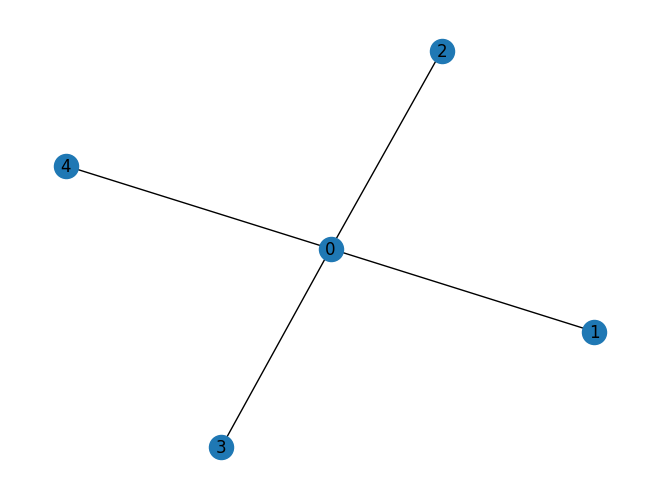

In [14]:
num_nodes = 5
edges = [(0, 1), (0, 2), (0, 3), (0, 4)]

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edges)
nx.draw(G, with_labels=True)

#### Mapping the MaxCut problem in a QAOA circuit ansatz

##### 1 - Trasforming the MaxCut instance in a quadratic problem

In [15]:
maxcut_prob = Maxcut(G)
maxcut_qp = maxcut_prob.to_quadratic_program()
print(maxcut_qp.prettyprint())

Problem name: Max-cut

Maximize
  -2*x_0*x_1 - 2*x_0*x_2 - 2*x_0*x_3 - 2*x_0*x_4 + 4*x_0 + x_1 + x_2 + x_3 + x_4

Subject to
  No constraints

  Binary variables (5)
    x_0 x_1 x_2 x_3 x_4



##### 2 - Defining the Hamiltonian by mapping the QUBO problem in an Ising Model

In [16]:
# MaxCut problem to Hamiltonian operator
hamiltonian, offset = maxcut_qp.to_ising()

##### 3 - Building the QAOA circuit based on the MaxCut instance

In [17]:
# QAOA ansatz circuit
qaoa_circuit = QAOAAnsatz(hamiltonian, reps=2)
qaoa_circuit.measure_all()
qaoa_circuit.decompose(reps=3).draw()

┌─────────────┐                                                »
   q_0: ┤ U3(π/2,0,π) ├──■────────────────────■─────────────────────■──»
        ├─────────────┤┌─┴─┐┌──────────────┐┌─┴─┐┌───────────────┐  │  »
   q_1: ┤ U3(π/2,0,π) ├┤ X ├┤ Rz(1.0*γ[0]) ├┤ X ├┤ R(2.0*β[0],0) ├──┼──»
        ├─────────────┤└───┘└──────────────┘└───┘└───────────────┘┌─┴─┐»
   q_2: ┤ U3(π/2,0,π) ├───────────────────────────────────────────┤ X ├»
        ├─────────────┤                                           └───┘»
   q_3: ┤ U3(π/2,0,π) ├────────────────────────────────────────────────»
        ├─────────────┤                                                »
   q_4: ┤ U3(π/2,0,π) ├────────────────────────────────────────────────»
        └─────────────┘                                                »
meas: 5/═══════════════════════════════════════════════════════════════»
                                                                       »
«                                                                        »
«   q_0: ──────────────────■─────────────────────■────────────────────■──»
«                          │                     │                    │  »
«   q_1: ──────────────────┼─────────────────────┼────────────────────┼──»
«        ┌──────────────┐┌─┴─┐┌───────────────┐  │                    │  »
«   q_2: ┤ Rz(1.0*γ[0]) ├┤ X ├┤ R(2.0*β[0],0) ├──┼────────────────────┼──»
«        └──────────────┘└───┘└───────────────┘┌─┴─┐┌──────────────┐┌─┴─┐»
«   q_3: ──────────────────────────────────────┤ X ├┤ Rz(1.0*γ[0]) ├┤ X ├»
«                                              └───┘└──────────────┘└───┘»
«   q_4: ────────────────────────────────────────────────────────────────»
«                                                                        »
«meas: 5/════════════════════════════════════════════════════════════════»
«                                                                        »
«                                                   ┌───────────────┐     »
«   q_0: ───────────────────■────────────────────■──┤ R(2.0*β[0],0) ├──■──»
«                           │                    │  └───────────────┘┌─┴─┐»
«   q_1: ───────────────────┼────────────────────┼───────────────────┤ X ├»
«                           │                    │                   └───┘»
«   q_2: ───────────────────┼────────────────────┼────────────────────────»
«        ┌───────────────┐  │                    │                        »
«   q_3: ┤ R(2.0*β[0],0) ├──┼────────────────────┼────────────────────────»
«        └───────────────┘┌─┴─┐┌──────────────┐┌─┴─┐┌───────────────┐     »
«   q_4: ─────────────────┤ X ├┤ Rz(1.0*γ[0]) ├┤ X ├┤ R(2.0*β[0],0) ├─────»
«                         └───┘└──────────────┘└───┘└───────────────┘     »
«meas: 5/═════════════════════════════════════════════════════════════════»
«                                                                         »
«                                                                              »
«   q_0: ──────────────────■────■─────────────────────■────■───────────────────»
«        ┌──────────────┐┌─┴─┐  │  ┌───────────────┐  │    │                   »
«   q_1: ┤ Rz(1.0*γ[1]) ├┤ X ├──┼──┤ R(2.0*β[1],0) ├──┼────┼───────────────────»
«        └──────────────┘└───┘┌─┴─┐└┬──────────────┤┌─┴─┐  │  ┌───────────────┐»
«   q_2: ─────────────────────┤ X ├─┤ Rz(1.0*γ[1]) ├┤ X ├──┼──┤ R(2.0*β[1],0) ├»
«                             └───┘ └──────────────┘└───┘┌─┴─┐└┬──────────────┤»
«   q_3: ────────────────────────────────────────────────┤ X ├─┤ Rz(1.0*γ[1]) ├»
«                                                        └───┘ └──────────────┘»
«   q_4: ──────────────────────────────────────────────────────────────────────»
«                                                                              »
«meas: 5/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«                                          

#### Setting up the Estimator and Sampler

In [18]:
quantum_backend = AerSimulator()

# Set the transpiler
pm = generate_preset_pass_manager(backend=quantum_backend, optimization_level=0)

# Set the Estimator and Sampler
estimator = Estimator(quantum_backend)
sampler = Sampler(quantum_backend)

#### Defining the cost function to be minimized

In [19]:
def cost_function(params, circuit, hamiltonian, estimator, pm):
    # Transpile the circuit to ISA circuit
    params = cp.asnumpy(params)
    circuit_isa = pm.run(circuit)
    hamiltonian_isa = hamiltonian.apply_layout(circuit_isa.layout)
    pub = (circuit_isa, [hamiltonian_isa], [params])

    # Submit the circuit to estimator and get the result
    result = estimator.run(pubs=[pub]).result()

    # Extract the expectation value
    cost = result[0].data.evs[0]
    return cost

#### Setting up the problem

In [20]:
cost_func = partial(cost_function, circuit=qaoa_circuit, hamiltonian=hamiltonian, estimator=estimator, pm=pm)
problem = Problem(n_params=qaoa_circuit.num_parameters, param_bounds=qaoa_circuit.parameter_bounds,
                  init_range=(0, 2* cp.pi), obj_function=cost_func, backend='gpu', vectorized=False)

#### Defining the CHC algorithm

In [21]:
optimizer = CHC(crossover=cx_blx_alpha, distance=fitness_l1)

#### Training the QAOA circuit

In [22]:
res = optimizer.optimize(problem, 10, max_nfev=100, seed=42)
res

Fitness Evaluations:  18%|███▏              | 18/100 [00:00<00:00, 130.30nfev/s]

********** Execution #1 **********
gen    nfev    min       max       mean       std
-----  ------  --------  --------  ---------  --------
0      10      -1.01929  0.398193  -0.397485  0.404733

1      2       -1.01929  0.398193  -0.397485  0.404733

2      6       -1.01929  -0.180908  -0.513013  0.278676


Fitness Evaluations:  32%|██████             | 32/100 [00:00<00:00, 91.84nfev/s]


3      6       -1.01929  -0.374512  -0.738574  0.230201

4      4       -1.01929  -0.499756  -0.789917  0.198326

5      2       -1.01929  -0.559326  -0.810059  0.176906

6      2       -1.01929  -0.559326  -0.810059  0.176906

7      4       -1.01929  -0.5625  -0.850708  0.160571


Fitness Evaluations:  56%|██████████▋        | 56/100 [00:00<00:00, 79.03nfev/s]

...

Fitness Evaluations:  99%|██████████████████▊| 99/100 [00:01<00:00, 77.06nfev/s]


14     8       -1.01929  -0.227051  -0.597925  0.29594

15     0       -1.01929  -0.227051  -0.597925  0.29594

16     6       -1.40649  -0.386475  -0.795483  0.271876

17     6       -1.5061  -0.566162  -0.907983  0.307864


Fitness Evaluations: 105nfev [00:01, 80.39nfev/s]                               


18     6       -1.5061  -0.566162  -0.907983  0.307864


  fun: array(-1.50610352)
  gen: 19
  log: {'gen': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], 'nfev': [10, 2, 6, 6, 4, 2, 2, 4, 6, 4, 2, 8, 10, 13, 8, 0, 6, 6, 6], 'min': [array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.01928711), array(-1.40649414), array(-1.50610352), array(-1.50610352)], 'max': [array(0.39819336), array(0.39819336), array(-0.1809082), array(-0.37451172), array(-0.49975586), array(-0.55932617), array(-0.55932617), array(-0.5625), array(-0.61083984), array(-0.66088867), array(-0.66088867), array(-0.70117188), array(-0.84179688), array(0.19018555), array(-0.22705078), array(-0.22705078), array(-0.38647461), array(-0.56616211), array(-0.56616211)], 'mean': [array(-0.39748535), array(-0.397

#### Testing the optimal angles found

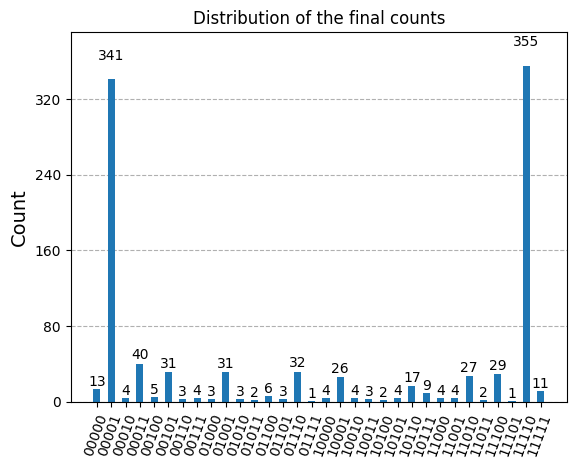

In [25]:
# Transpile the circuit to ISA circuit
params = cp.asnumpy(res.x)
qaoa_isa = pm.run(qaoa_circuit)
pub = (qaoa_isa, params)

# Submit the circuit to sampler
job = sampler.run([pub])

# Collect data to get the counts
pub_results = job.result()[0]
counts = pub_results.data.meas.get_counts()

plot_histogram(counts, title='Distribution of the final counts')

In [26]:
bitstring = maxcut_prob.sample_most_likely(counts)
print('Optimal solution: ', bitstring)

Optimal solution:  [0 1 1 1 1]


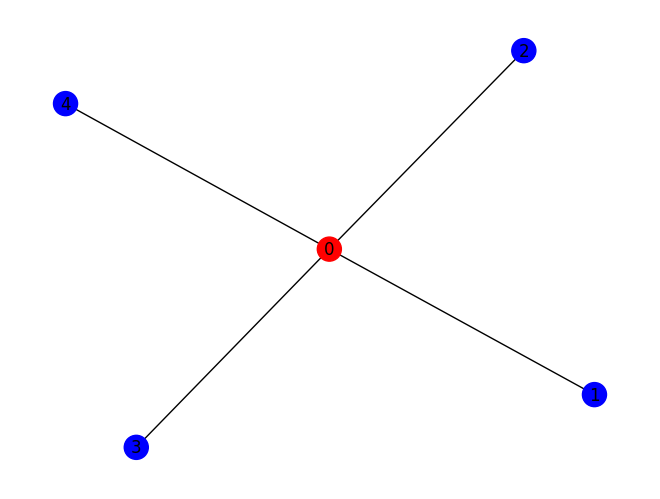

In [27]:
maxcut_prob.draw(bitstring)

# Train Variational Quantum Classifiers by using f-evovaq and PennyLane


#### Importing modules

In [2]:
import numpy as np
import cupy as cp
from functools import partial
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from fevovaq.problem import Problem
from fevovaq.GeneticAlgorithm import GA
from fevovaq.tools.operators import sel_tournament, cx_uniform, mut_gaussian
import pennylane as qml

#### Defining functions

In [13]:
def setup_pennylane_circuit(n_qubits, reps):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface=None, diff_method=None)
    def circuit(inputs, weights):
        weights = cp.asnumpy(weights)
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        weights = weights.reshape(reps, n_qubits, 3)
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return qml.probs(wires=0)

    return circuit


def cost_function(params, qnode, train_data, train_labels):
    """
    Compute the probability of being in state |1> and use it to compute log_loss.
    """
    probs = qnode(train_data, params)
    return log_loss(train_labels, probs[:, 1])


def get_label(params, qnode, test_data):
    "Predict label for each test istance"
    probs = qnode(test_data, params)

    return 1 if probs[1] > 0.5 else 0

#### Loading dataset and quantum model

In [14]:
data = load_iris()
features = data.data[:100, :]
target = data.target[:100]  # 0 or 1

train_data, test_data, train_labels, test_labels = train_test_split(features, target, test_size=0.3,
                                                                random_state=123, stratify=target)

# Pre-processing
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
scaler.fit(train_data)
train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

n_qubits = train_data.shape[1]  # Number of qubits
qnode = setup_pennylane_circuit(n_qubits, 5)

n_params = 5 * n_qubits * 3 # Number of trainable parameters
print('Number of parameters involved: {}'.format(n_params))

Number of parameters involved: 60


#### Setting up the problem and optimizer

In [15]:
cost_func = partial(cost_function, qnode=qnode,
                train_data=train_data, train_labels=train_labels)

problem = Problem(n_params=n_params, param_bounds=(- cp.pi, cp.pi), init_range=(- cp.pi, cp.pi), obj_function=cost_func, backend='gpu', vectorized=False)

In [16]:
optimizer = GA(
    selection=sel_tournament,
    crossover=cx_uniform,
    mutation=mut_gaussian,
    cxpb=0.9,
    mut_indpb=0.25
)


#### Training the quantum classifier

In [18]:
res = optimizer.optimize(problem, pop_size=10, max_gen=20, seed=1, verbose=True)
res

Generations:  10%|███                           | 2/20 [00:00<00:00, 19.65gen/s]

********** Execution #1 **********
gen    nfev    min       max       mean      std
-----  ------  --------  --------  --------  ---------
0      10      0.650329  0.947386  0.747862  0.0918746

1      10      0.64318  0.912444  0.72793  0.0802623

2      10      0.601074  0.72883  0.662113  0.0372224

3      10      0.601074  0.800428  0.677  0.0634095

4      10      0.601074  0.902105  0.721889  0.100713


Generations:  40%|████████████                  | 8/20 [00:00<00:00, 20.03gen/s]


5      10      0.598125  0.839488  0.702297  0.0793839

6      10      0.598125  0.881257  0.72386  0.08676

7      10      0.481134  0.798423  0.666046  0.0983832

8      10      0.425562  0.76862  0.580563  0.0991216

9      10      0.425562  0.816829  0.635246  0.152609


Generations:  65%|██████████████████▊          | 13/20 [00:00<00:00, 19.97gen/s]

...

Generations:  80%|███████████████████████▏     | 16/20 [00:00<00:00, 20.02gen/s]


14     10      0.40962  0.831035  0.678999  0.11337

15     10      0.40962  0.731908  0.585875  0.11345

16     10      0.403068  0.87274  0.636615  0.157095

17     10      0.403068  0.883448  0.666935  0.130822

18     10      0.403068  0.916513  0.664277  0.139977


Generations: 100%|█████████████████████████████| 20/20 [00:00<00:00, 20.01gen/s]



19     10      0.403068  0.973204  0.666048  0.168796

20     10      0.403068  0.907873  0.733743  0.140554


  fun: array(0.40306812)
  gen: 20
  log: {'gen': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'nfev': [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], 'min': [array(0.65032899), array(0.64318014), array(0.60107355), array(0.60107355), array(0.60107355), array(0.59812518), array(0.59812518), array(0.48113362), array(0.42556227), array(0.42556227), array(0.40962049), array(0.40962049), array(0.40962049), array(0.40962049), array(0.40962049), array(0.40962049), array(0.40306812), array(0.40306812), array(0.40306812), array(0.40306812), array(0.40306812)], 'max': [array(0.94738568), array(0.91244404), array(0.72883022), array(0.80042805), array(0.90210504), array(0.83948786), array(0.88125667), array(0.79842266), array(0.76862013), array(0.81682863), array(0.84333495), array(0.92728622), array(0.85146369), array(0.72762343), array(0.83103504), array(0.73190822), array(0.87274045), array(0.88344844), array(0.91651345), arr

#### Testing the obtained solution

In [19]:
test_preds = [get_label(res.x, qnode, feats) for feats in test_data]

test_accuracy = accuracy_score(test_labels, test_preds)
print("Test accuracy", test_accuracy)

Test accuracy 0.9333333333333333
